In [16]:
import pandas
import matplotlib.pyplot as plt


In [17]:
import glob
import os
import pickle
import re

save_dir = "/glade/work/stevenxu/AMOC_models"
batch_pattern = os.path.join(save_dir, "Fgen_Allmodels*.pkl")
single_path = os.path.join(save_dir, "Fgen_Allmodels.pkl")

batch_regex = re.compile(r"Fgen_Allmodels(\d+)\.pkl$")
numbered_batches = []
for p in glob.glob(batch_pattern):
    m = batch_regex.search(os.path.basename(p))
    if m:
        numbered_batches.append((int(m.group(1)), p))

if numbered_batches:
    load_paths = [p for _, p in sorted(numbered_batches)]
else:
    if not os.path.exists(single_path):
        raise FileNotFoundError(f"No batch PKL files found with pattern: {batch_pattern}")
    load_paths = [single_path]

Fgen_dict = {}
for p in load_paths:
    with open(p, "rb") as f:
        chunk = pickle.load(f)
    if not isinstance(chunk, dict):
        raise TypeError(f"Expected dict in {p}, got {type(chunk)}")

    overlap = set(Fgen_dict).intersection(chunk)
    if overlap:
        print(f"Warning: {len(overlap)} overlapping models in {os.path.basename(p)}; later file overrides earlier entries.")

    Fgen_dict.update(chunk)
    print(f"Loaded {len(chunk)} models from {os.path.basename(p)}")

print(f"Total models loaded: {len(Fgen_dict)}")

Fgen_dict


Loaded 3 models from Fgen_Allmodels1.pkl
Loaded 3 models from Fgen_Allmodels2.pkl
Loaded 3 models from Fgen_Allmodels3.pkl
Loaded 3 models from Fgen_Allmodels4.pkl
Total models loaded: 12


{'ACCESS-CM2':         rho          Fgen      HeatFlux  FreshwaterFlux  AreaSum
 0   1014.75 -4.605178e+03 -3.842845e+03     -762.332854      0.0
 1   1015.25 -4.605178e+03 -3.842845e+03     -762.332854      0.0
 2   1015.75 -2.558432e+03 -2.134914e+03     -423.518252      0.0
 3   1016.25 -4.605178e+03 -3.842845e+03     -762.332854      0.0
 4   1016.75 -4.605178e+03 -3.842845e+03     -762.332854      0.0
 5   1017.25 -3.070119e+03 -2.561897e+03     -508.221903      0.0
 6   1017.75 -3.070119e+03 -2.561897e+03     -508.221903      0.0
 7   1018.25 -5.628551e+03 -4.696811e+03     -931.740155      0.0
 8   1018.75 -7.675297e+03 -6.404742e+03    -1270.554756      0.0
 9   1019.25 -1.023373e+04 -8.539656e+03    -1694.073009      0.0
 10  1019.75 -9.722043e+03 -8.112673e+03    -1609.369358      0.0
 11  1020.25 -2.404926e+04 -2.006819e+04    -3981.071570      0.0
 12  1020.75 -5.475045e+04 -4.568716e+04    -9063.290596      0.0
 13  1021.25 -5.526214e+04 -4.611414e+04    -9147.994246      

In [18]:
Fgen_dict.keys()

dict_keys(['ACCESS-CM2', 'ACCESS-ESM1-5', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CanESM5', 'EC-Earth3', 'EC-Earth3-LR', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G'])

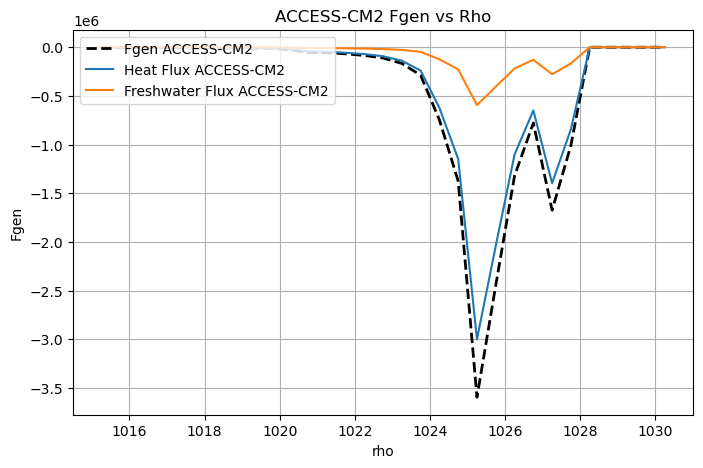

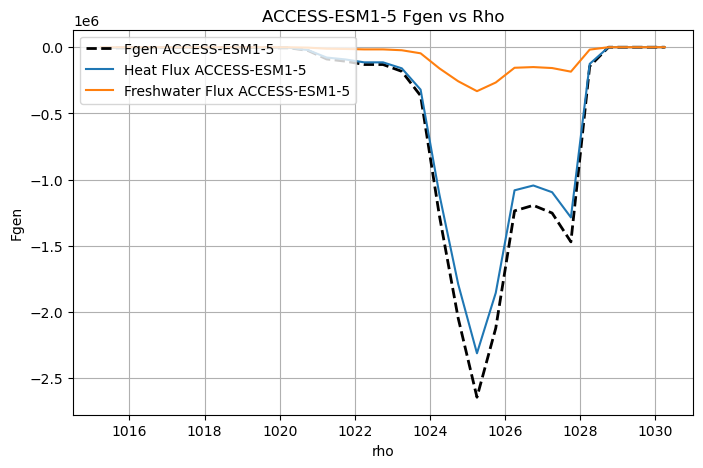

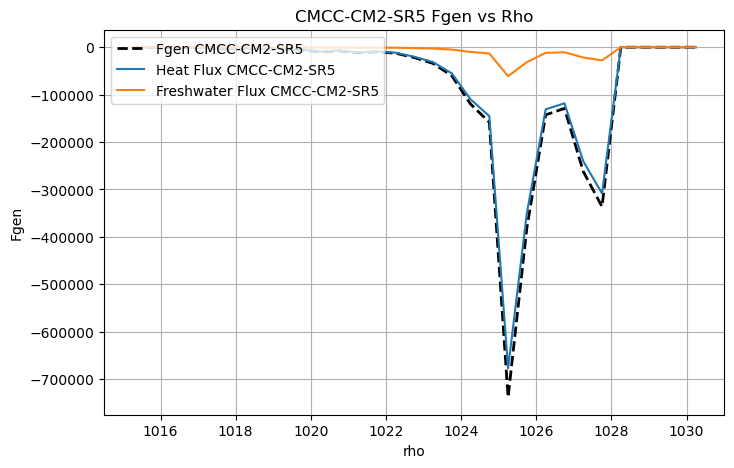

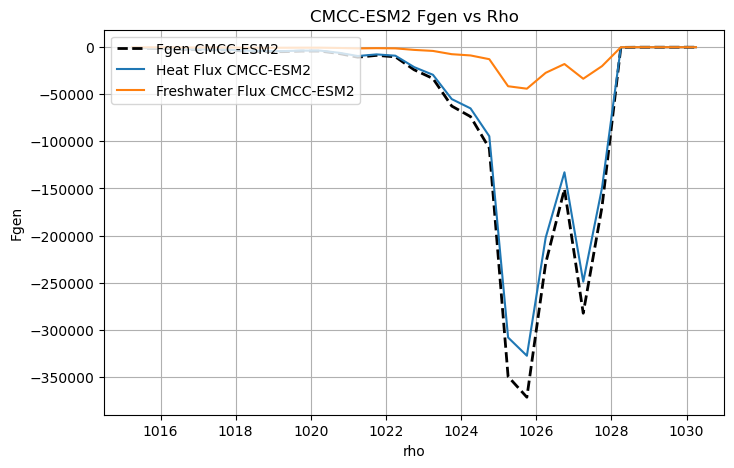

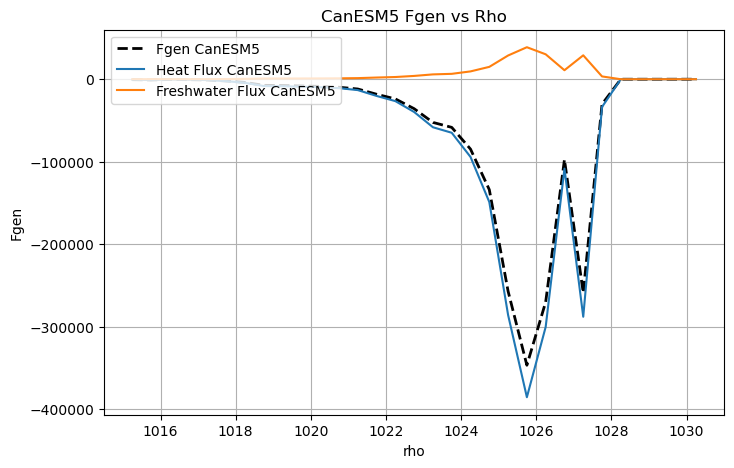

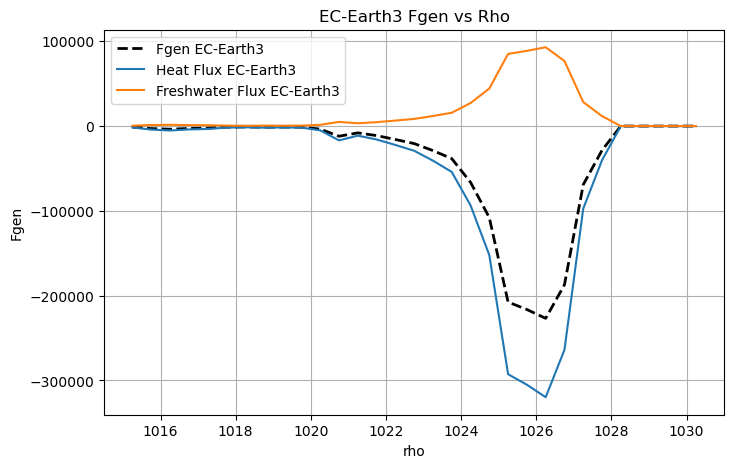

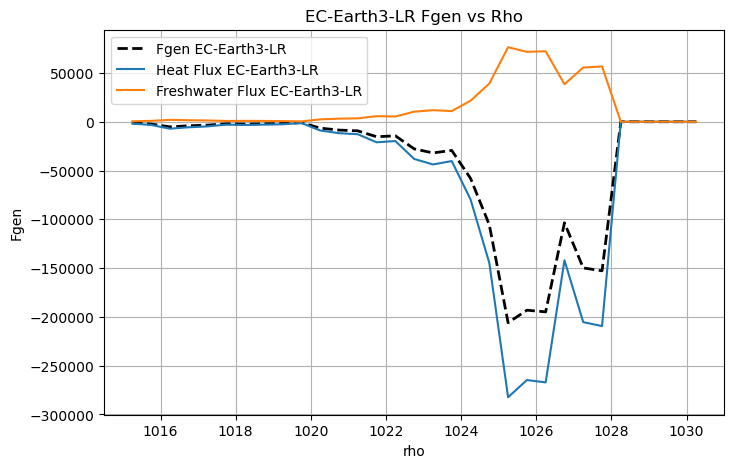

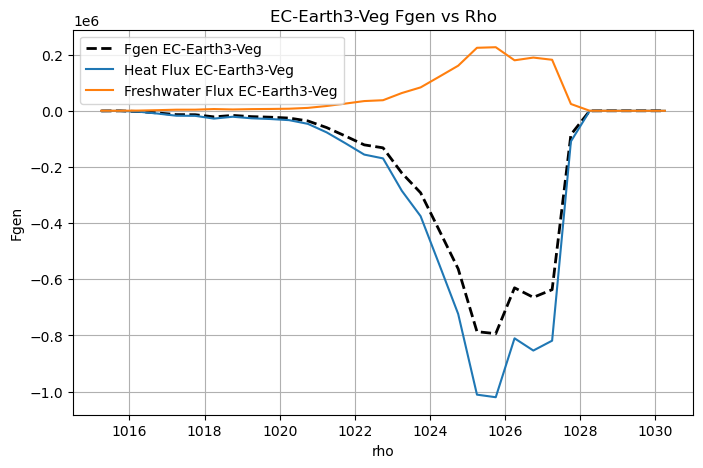

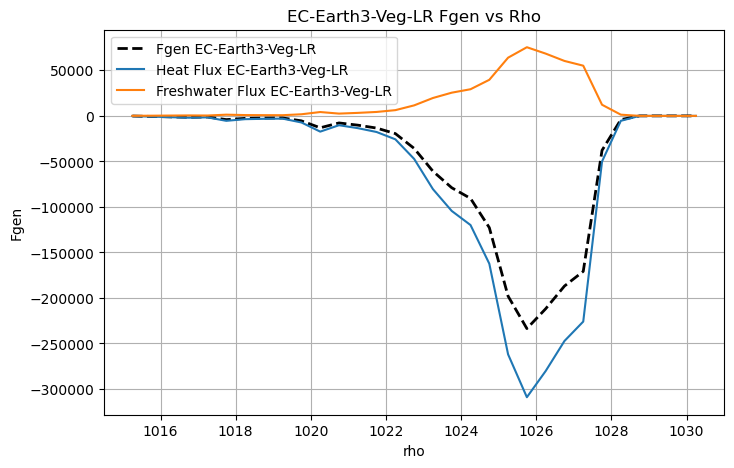

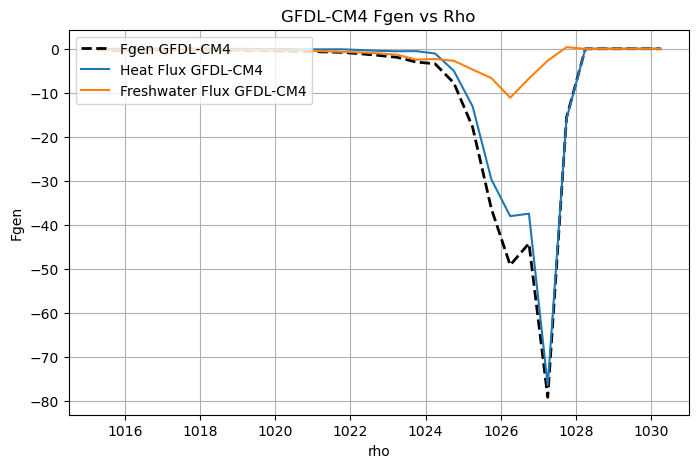

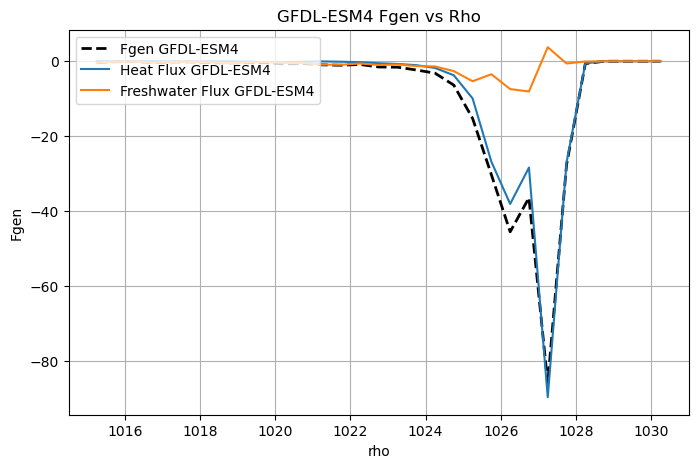

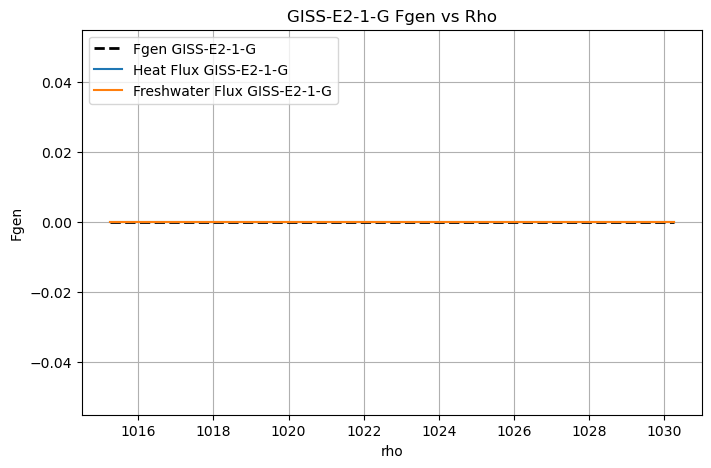

In [19]:
for model, Fgen in Fgen_dict.items():
    Fgen_clip = Fgen[(Fgen['rho'] >1015)]
    plt.figure(figsize=(8,5))
    plt.plot(Fgen_clip['rho'], Fgen_clip['Fgen'],'--', label = f'Fgen {model}', color = 'black', linewidth=2)
    plt.plot(Fgen_clip['rho'], Fgen_clip['HeatFlux'], label=f'Heat Flux {model}')
    plt.plot(Fgen_clip['rho'], Fgen_clip['FreshwaterFlux'], label=f'Freshwater Flux {model}')
    #plt.plot(Fgen_clip['rho'], Fgen_clip['AreaSum'], label=f'Area {model}')

    plt.xlabel('rho')
    plt.ylabel('Fgen')
    plt.title(model + ' Fgen vs Rho')
    plt.grid(True)
    plt.legend(loc='upper left')
    plt.show()

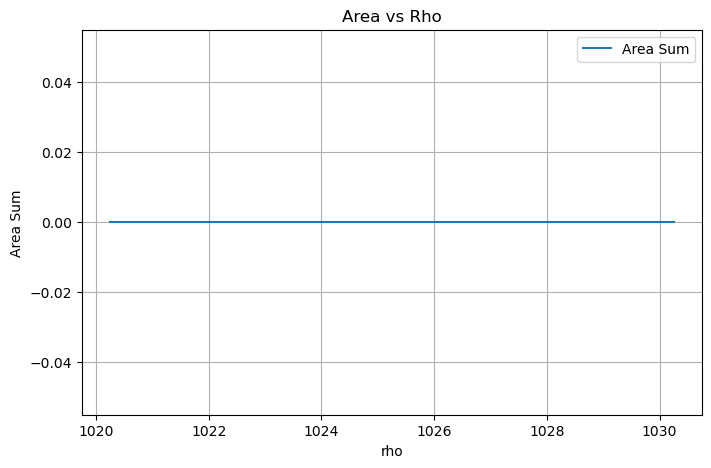

In [20]:
Fgen_clip = Fgen[(Fgen['rho'] >1020)]
plt.figure(figsize=(8,5))
plt.plot(Fgen_clip['rho'], Fgen_clip['AreaSum'], label = 'Area Sum')

plt.xlabel('rho')
plt.ylabel('Area Sum')
plt.title('Area vs Rho')
plt.grid(True)
plt.legend(loc='upper right')
plt.show()